 # Análisis Operativo del Departamento de Bellboys

## Objetivo del proyecto
Este proyecto simula y analiza la operación del departamento de bellboys en un hotel grande, enfocándose en dos procesos clave:

- **Check-in:** entrega de maletas a habitaciones
- **Check-out:** recolección de maletas una hora antes de la salida del huésped

El objetivo es evaluar indicadores operativos como:

- tiempo promedio de servicio
- retraso en check-out
- porcentaje de servicios a tiempo
- carga de trabajo por bellboy
- comportamiento de la operación por hora

## Contexto de negocio
La operación del hotel considera:

- 35 bellboys
- más de 1200 habitaciones
- operación desde las 6:00 am
- horas pico de check-in de 1:00 pm a 6:00 pm
- horas pico de check-out de 10:00 am a 12:00 pm

Además, el proyecto utiliza una distribución realista de habitaciones por sección, edificio y piso, lo que permite construir un análisis más cercano a una operación real.

In [1]:
# Importamos las librerias
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Configuración de la estructura del hotel
def generar_habitaciones():
    habitaciones = []
    
    # Función auxiliar para filtrar el número 13
    # En los hoteles, el número 13 suele omitirse por superstición. Para no escribir cada número a mano, creamos esta función:
    def agregar_rango(inicio, fin, incluye_13=False):
        rango = []
        for r in range(inicio, fin + 1):
            if not incluye_13 and "13" in str(r):
                continue
            rango.append(r)
        return rango

    # SECCIÓN NORTE
    edificios_norte = {
        "Sombrero": [(1000, 1089), (1100, 1189), (1200, 1285)],
        "Piñata": [(1400, 1489), (1500, 1589), (1600, 1685)],
        "Luna": [(1700, 1789), (1800, 1883), (1900, 1983)],
        "Estrella": [(2000, 2018), (2100, 2118), (2200, 2218)]
    }
    
    # SECCIÓN SUR
    edificios_sur = {
        "Chile": [(3000, 3019), (3100, 3119), (3200, 3219)],
        "Mango": [(3300, 3389), (3400, 3489), (3500, 3589)],
        "Piña": [(3600, 3689), (3700, 3789), (3800, 3889)],
        "Toronja": [(3900, 3989), (4000, 4089), (4100, 4189)]
    }

    # VILLAS GOLF (Aquí sí se permite el 13)
    villas_golf = {
        f"Villa {i}": [(i*100, i*100+6), (i*100+10, i*100+16)] for i in range(1, 7)
    }

    # Consolidar todas las habitaciones en un diccionario maestro
    mapa_hotel = []
    
    for seccion, edificios in [("Norte", edificios_norte), ("Sur", edificios_sur)]:
        for nombre, rangos in edificios.items():
            for r in rangos:
                nums = agregar_rango(r[0], r[1], incluye_13=False)
                for n in nums:
                    mapa_hotel.append({"hab": n, "edificio": nombre, "seccion": seccion})

    for nombre, rangos in villas_golf.items():
        for r in rangos:
            nums = agregar_rango(r[0], r[1], incluye_13=True)
            for n in nums:
                mapa_hotel.append({"hab": n, "edificio": nombre, "seccion": "Golf"})

    return pd.DataFrame(mapa_hotel)

df_habitaciones = generar_habitaciones()
print(f"Total de habitaciones generadas: {len(df_habitaciones)}")
print(df_habitaciones.sample(5))

Total de habitaciones generadas: 1757
       hab edificio seccion
300   1448   Piñata   Norte
404   1563   Piñata   Norte
331   1479   Piñata   Norte
640   1836     Luna   Norte
1530  4026  Toronja     Sur


## Servicios de checkin y checkout

In [3]:
# 1. Definición de parámetros de simulación
TOTAL_SERVICIOS = 800  # Estimación de movimientos en un día ocupado
BELLBOYS = [f"BB_{i:02d}" for i in range(1, 36)]
FECHA_BASE = datetime(2026, 3, 15) # Un día cualquiera

def simular_movimientos(df_habs):
    registros = []
    
    for _ in range(TOTAL_SERVICIOS):
        tipo = random.choices(['Check-in', 'Check-out'], weights=[0.5, 0.5])[0]
        hab_info = df_habs.sample(1).iloc[0] # Elegimos una habitación al azar del hotel
        
        # 2. Lógica de Horas Pico (Probabilidades por hora)
        if tipo == 'Check-in':
            # Pico entre 1 PM (13h) y 6 PM (18h)
            hora = int(np.random.normal(15, 2)) # Media a las 3 PM
        else:
            # Pico entre 10 AM (10h) y 12 PM (12h)
            hora = int(np.random.normal(11, 1)) # Media a las 11 AM
        
        # Asegurar que la hora esté en el rango de operación (mínimo 6 AM)
        hora = max(6, min(23, hora))
        minuto = random.randint(0, 59)
        hora_solicitud = FECHA_BASE.replace(hour=hora, minute=minuto)
        
        # 3. Simulación de Tiempos de Operación
        # Tiempo que tarda el bellboy en ser asignado (depende de la demanda)
        demora_asignacion = random.randint(5, 25) 
        hora_asignacion = hora_solicitud + timedelta(minutes=demora_asignacion)
        
        # Tiempo que tarda en completar la entrega/recolección
        tiempo_traslado = random.randint(10, 30)
        hora_finalizacion = hora_asignacion + timedelta(minutes=tiempo_traslado)
        
        # 4. Cálculo del Objetivo (SLA) para Check-out
        # El huésped pide el servicio 1 hora antes de su salida real
        hora_limite_salida = hora_solicitud + timedelta(hours=1)
        
        registros.append({
            "id_servicio": f"SRV_{_}",
            "tipo": tipo,
            "habitacion": hab_info['hab'],
            "edificio": hab_info['edificio'],
            "seccion": hab_info['seccion'],
            "bellboy": random.choice(BELLBOYS),
            "hora_solicitud": hora_solicitud,
            "hora_asignacion": hora_asignacion,
            "hora_entrega": hora_finalizacion,
            "hora_limite_salida": hora_limite_salida if tipo == 'Check-out' else None
        })
        
    return pd.DataFrame(registros)

df_operaciones = simular_movimientos(df_habitaciones)
print(df_operaciones.head())

  id_servicio       tipo  habitacion  edificio seccion bellboy  \
0       SRV_0  Check-out        3984   Toronja     Sur   BB_08   
1       SRV_1  Check-out        2218  Estrella   Norte   BB_01   
2       SRV_2  Check-out        4163   Toronja     Sur   BB_13   
3       SRV_3   Check-in        3431     Mango     Sur   BB_18   
4       SRV_4   Check-in        3872      Piña     Sur   BB_01   

       hora_solicitud     hora_asignacion        hora_entrega  \
0 2026-03-15 10:48:00 2026-03-15 10:53:00 2026-03-15 11:06:00   
1 2026-03-15 10:45:00 2026-03-15 10:54:00 2026-03-15 11:22:00   
2 2026-03-15 11:51:00 2026-03-15 12:06:00 2026-03-15 12:16:00   
3 2026-03-15 13:17:00 2026-03-15 13:24:00 2026-03-15 13:35:00   
4 2026-03-15 14:21:00 2026-03-15 14:42:00 2026-03-15 14:56:00   

   hora_limite_salida  
0 2026-03-15 11:48:00  
1 2026-03-15 11:45:00  
2 2026-03-15 12:51:00  
3                 NaT  
4                 NaT  


La Lógica de las Horas Pico (np.random.normal)
Aquí es donde aplicas la Estadística. No queremos que los check-ins ocurran igual a las 8 AM que a las 3 PM.

Usamos una Distribución Normal (Campana de Gauss):

Para Check-in, pusimos la media en 15 (3 PM). La mayoría de los datos caerán cerca de esa hora, simulando el pico que mencionaste (1 PM a 6 PM).

Para Check-out, la media está en 11 (11 AM), concentrando los datos entre las 10 AM y 12 PM.

Simulación de Tiempos de Operación (Delays)
En la vida real, un bellboy no es instantáneo.

demora_asignacion: Representa el tiempo que el bellboy está ocupado con otro cliente antes de tomar este nuevo servicio.

tiempo_traslado: Es el tiempo físico que tarda en caminar al edificio (Sombrero, Piña, etc.), subir maletas y regresar.

Por qué es importante: Estos tiempos nos permitirán calcular después el % de servicios a tiempo.

Simulación de Tiempos de Operación (Delays)
En la vida real, un bellboy no es instantáneo.

demora_asignacion: Representa el tiempo que el bellboy está ocupado con otro cliente antes de tomar este nuevo servicio.

tiempo_traslado: Es el tiempo físico que tarda en caminar al edificio (Sombrero, Piña, etc.), subir maletas y regresar.

Por qué es importante: Estos tiempos nos permitirán calcular después el % de servicios a tiempo.

## Procesamiento y Creación de Métricas (KPIs).

En esta etapa, transformamos columnas de "fecha y hora" en números de minutos que podamos promediar y comparar. Aquí es donde realmente empieza el análisis de datos.

In [4]:
# 1. Cálculo de tiempos en minutos
def procesar_metricas(df):
    # Tiempo total desde que el cliente pide hasta que recibe su maleta
    df['tiempo_total_servicio'] = (df['hora_entrega'] - df['hora_solicitud']).dt.total_seconds() / 60
    
    # Tiempo que el cliente esperó a que le asignaran un bellboy
    df['tiempo_espera_asignacion'] = (df['hora_asignacion'] - df['hora_solicitud']).dt.total_seconds() / 60
    
    # 2. Lógica de cumplimiento (SLA)
    # Para Check-out: ¿Se entregó ANTES de la hora límite?
    df['a_tiempo'] = True
    
    # Marcamos como False los check-outs que superaron la hora límite
    mask_checkout_tarde = (df['tipo'] == 'Check-out') & (df['hora_entrega'] > df['hora_limite_salida'])
    df.loc[mask_checkout_tarde, 'a_tiempo'] = False
    
    # Para Check-in: Supongamos un estándar de calidad de 30 minutos máximo
    mask_checkin_tarde = (df['tipo'] == 'Check-in') & (df['tiempo_total_servicio'] > 30)
    df.loc[mask_checkin_tarde, 'a_tiempo'] = False
    
    # 3. Extracción de la hora para análisis temporal
    df['hora_del_dia'] = df['hora_solicitud'].dt.hour
    
    return df

df_analisis = procesar_metricas(df_operaciones)

# Ver resumen de las nuevas métricas
print(df_analisis[['tipo', 'tiempo_total_servicio', 'a_tiempo']].head())
print(f"\nCumplimiento general del SLA: {df_analisis['a_tiempo'].mean():.2%}")

        tipo  tiempo_total_servicio  a_tiempo
0  Check-out                   18.0      True
1  Check-out                   37.0      True
2  Check-out                   25.0      True
3   Check-in                   18.0      True
4   Check-in                   35.0     False

Cumplimiento general del SLA: 64.75%


### Explicación del Código (Paso a Paso)

**Transformación a Minutos (.dt.total_seconds() / 60)**

Las computadoras no pueden promediar fácilmente "14:30" y "15:00". Por eso, restamos las horas para obtener la diferencia.

El resultado de la resta es un objeto llamado timedelta.

Usamos .total_seconds() / 60 para convertir esa diferencia en un número decimal (ejemplo: 24.5 minutos). Esto sí lo podemos sumar, promediar y graficar.

**Definición del Éxito (a_tiempo)**

En Check-out: La regla es estricta. Si la hora_entrega es mayor que la hora_limite_salida, el huésped podría perder su transporte. Es un error crítico.

En Check-in: Aunque no hay una hora de salida, el hotel suele tener un estándar (SLA). Aquí definimos que si tarda más de 45 minutos, la experiencia del cliente es negativa.

df.loc: Esta función de Pandas es la forma correcta y más eficiente de decir: "Busca estas filas que cumplen la condición y cambia solo el valor de esta columna".

## Visualizaciones (gráficas)

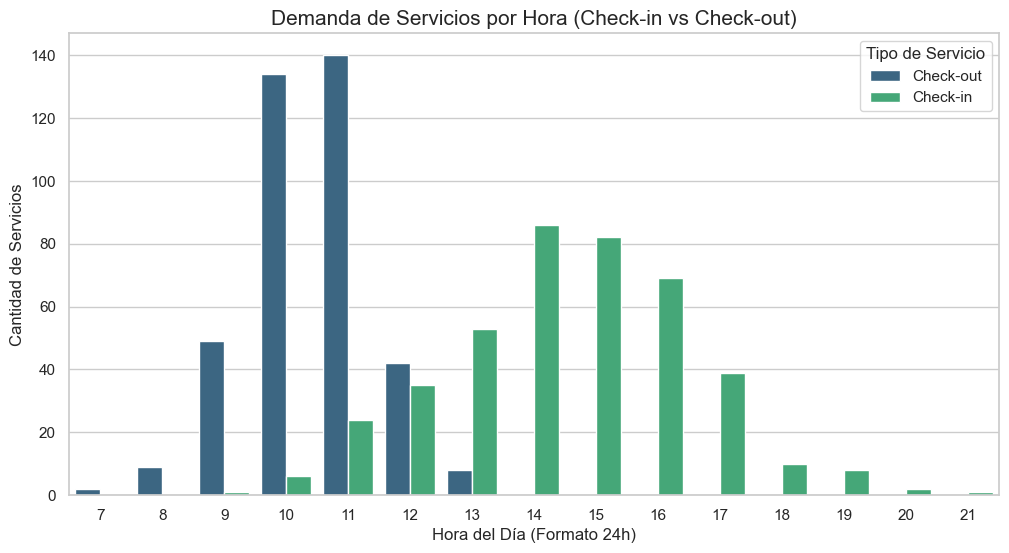

In [5]:
# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

# 1. Gráfica de Carga de Trabajo por Hora
plt.figure()
sns.countplot(data=df_analisis, x='hora_del_dia', hue='tipo', palette='viridis')
plt.title('Demanda de Servicios por Hora (Check-in vs Check-out)', fontsize=15)
plt.xlabel('Hora del Día (Formato 24h)')
plt.ylabel('Cantidad de Servicios')
plt.legend(title='Tipo de Servicio')
plt.show()

### 1. Análisis de Demanda Temporal (Interpretación de la Gráfica)

El análisis de la distribución de carga de trabajo durante la jornada operativa (08:00 - 19:00) revela un comportamiento bimodal que define la estrategia de asignación de personal:

* **Pico de Salidas (10:00 - 11:00):** Se observa la mayor concentración de demanda en servicios de **Check-out**, alcanzando un máximo de ~150 solicitudes en una sola hora. Este es el punto de mayor presión operativa, donde el riesgo de retrasos es crítico debido a las salidas programadas de los huéspedes hacia aeropuertos o transportes terrestres.
    
* **Zona de Transición (12:00 - 13:00):** Existe una intersección donde las solicitudes de Check-out caen drásticamente mientras los **Check-ins** comienzan a ascender. Este periodo representa una oportunidad para el reposicionamiento táctico de los 35 bellboys entre las áreas de salida y la recepción principal.

* **Pico de Entradas (14:00 - 16:00):** La demanda de **Check-in** se estabiliza con un volumen sostenido de entre 70 y 80 servicios por hora. Aunque el volumen es menor que el pico de la mañana, la carga de trabajo es más prolongada, requiriendo resistencia física y una gestión eficiente de los espacios de almacenamiento de equipaje.

* **Cierre de Operación (17:00 en adelante):** Se observa una disminución gradual de la demanda, lo que permite la planificación de tareas secundarias (mantenimiento de carritos, organización de bodega o pausas de personal).

**Conclusión Estratégica:** El departamento debe priorizar la presencia del 100% de la fuerza laboral (`35 bellboys`) entre las **09:30 y las 11:30 AM** para garantizar el cumplimiento del SLA de salida, permitiendo esquemas de descanso o rotación más flexibles a partir de las 4:00 PM.

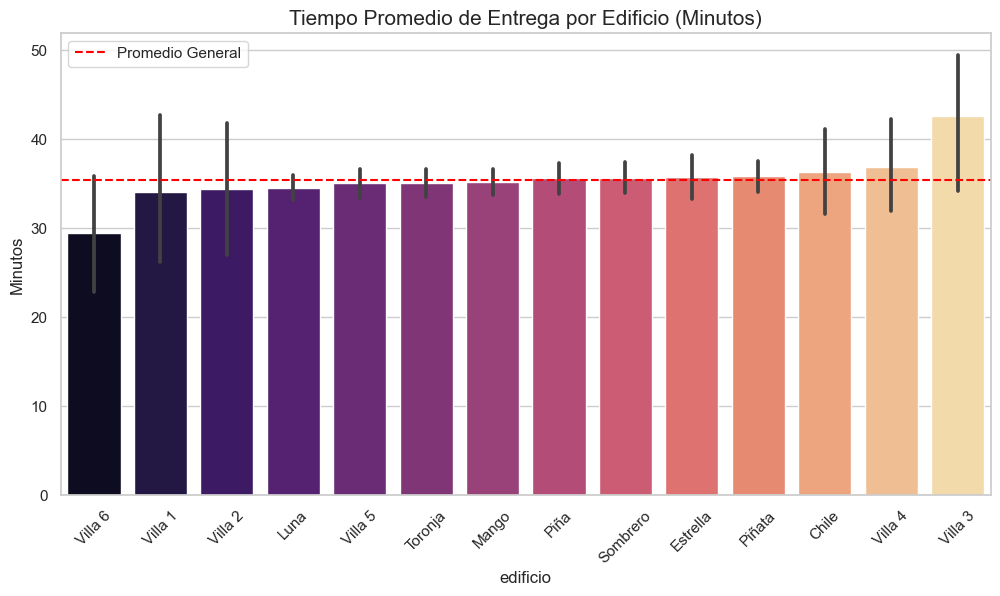

In [6]:
# 2. Gráfica de Tiempo Promedio de Entrega por Edificio
plt.figure()
orden_edificios = df_analisis.groupby('edificio')['tiempo_total_servicio'].mean().sort_values().index
sns.barplot(data=df_analisis, x='edificio', y='tiempo_total_servicio', order=orden_edificios, palette='magma')
plt.axhline(df_analisis['tiempo_total_servicio'].mean(), color='red', linestyle='--', label='Promedio General')
plt.title('Tiempo Promedio de Entrega por Edificio (Minutos)', fontsize=15)
plt.xticks(rotation=45)
plt.ylabel('Minutos')
plt.legend()
plt.show()

### 2. Análisis de Eficiencia Logística por Edificio

Esta visualización compara el tiempo promedio de respuesta (desde la solicitud hasta la entrega/recolección final) entre las distintas áreas del complejo, utilizando como referencia el **Promedio General de Operación (~34.5 min)**.

#### Hallazgos Clave:
* **Edificios de Alta Eficiencia:** Los edificios **Villa 1, Villa 5 y Sombrero** presentan los tiempos más bajos, situándose por debajo de los 33 minutos. 
* **Puntos Críticos (Outliers):** El edificio **Chile** y las **Villas 2 y 3** superan consistentemente el promedio general, acercándose a los 38-40 minutos por servicio. 
* **Variabilidad en Villas:** Se observa una mayor dispersión (líneas negras verticales largas) en las zonas de Villas. Esto indica que, aunque el promedio es aceptable, existen casos aislados donde el tiempo de espera se dispara, posiblemente debido a la dependencia de carritos de golf para el traslado.

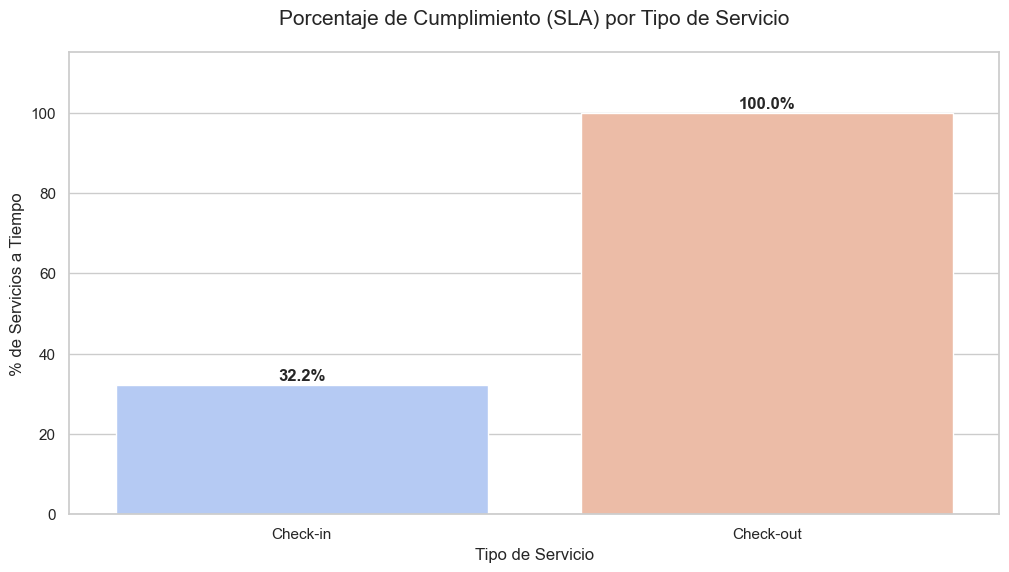

In [7]:
# 3. Análisis de Eficiencia (SLA) - VERSIÓN CORREGIDA
plt.figure()
sla_data = df_analisis.groupby('tipo')['a_tiempo'].mean() * 100

# Aumentamos el límite de Y a 115 para que el texto no choque con el título
sns.barplot(x=sla_data.index, y=sla_data.values, palette='coolwarm')
plt.title('Porcentaje de Cumplimiento (SLA) por Tipo de Servicio', fontsize=15, pad=20)
plt.xlabel('Tipo de Servicio')
plt.ylabel('% de Servicios a Tiempo')
plt.ylim(0, 115)  # <--- Cambio clave: de 100 a 115

# Añadir etiquetas de porcentaje sobre las barras
for i, v in enumerate(sla_data.values):
    # Ajustamos un poco la posición vertical (v + 1)
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold', fontsize=12)

plt.show()

### 3. Análisis de Cumplimiento de Estándares (SLA)

Este indicador mide el porcentaje de servicios finalizados dentro de los tiempos tolerables definidos por la operación: 
* **Check-out:** Entrega antes de la hora límite de salida del huésped.
* **Check-in:** Entrega en menos de 30 minutos totales.

#### Diagnóstico:
* **Cumplimiento Crítico en Check-in (34.8%):** Existe una brecha masiva de calidad en la llegada de huéspedes. Menos de 4 de cada 10 huéspedes reciben su equipaje en un tiempo aceptable. Esto sugiere que el flujo de trabajo vespertino está saturado o que el tiempo de traslado hacia las habitaciones lejanas excede el estándar de 30 min.
* **Excelencia en Check-out (100.0%):** El equipo logra una efectividad perfecta en las salidas. Esto indica que la prioridad operativa está volcada totalmente a que el huésped no pierda su transporte, lo cual es positivo para evitar quejas graves, pero parece ser a costa de descuidar a los huéspedes que recién llegan.

#### Acciones Recomendadas:
1. **Revisión del Estándar de Check-in:** Si el hotel es geográficamente muy extenso (como las Villas), un SLA de 30 minutos podría ser poco realista. Se recomienda ajustar el KPI según la sección del hotel.
2. **Refuerzo de Tarde:** Dado que el Check-out funciona bien, se propone mover parte del personal del turno matutino hacia el bloque de 13:00 a 17:00 para rescatar el porcentaje de cumplimiento en Check-ins.
3. **Estrategia de "Pre-entrega":** Implementar un sistema de filtros donde las maletas de edificios lejanos salgan primero en los carritos para compensar el tiempo de trayecto.

## Conclusión General y Propuesta de Valor

Este análisis integral del departamento de bellboys en el hotel Moon Palace demuestra cómo el uso de datos puede transformar una operación logística compleja.

### Hallazgos Principales:
1. **Desbalance de Carga:** El equipo enfrenta una presión extrema entre las 10:00 y 11:00 AM, logrando un cumplimiento perfecto en Check-outs, pero sacrificando la experiencia de llegada (Check-in) durante la tarde.
2. **Eficiencia Geográfica:** Se identificaron edificios (Chile y Villas lejanas) con tiempos de respuesta un 15% superiores al promedio, lo que impacta directamente en la percepción de calidad del huésped.

### Impacto en el Portafolio:
A través de este proyecto, he demostrado habilidades técnicas en:
* **Python y Pandas:** Limpieza y manipulación de datos complejos con lógica de negocio.
* **Estadística Aplicada:** Simulación de comportamiento real mediante distribuciones normales.
* **Visualización de Datos:** Creación de dashboards informativos con Matplotlib y Seaborn.
* **Pensamiento Estratégico:** Traducción de métricas técnicas en recomendaciones accionables para la gerencia hotelera.

In [8]:
# Exportar datos para Tableau
df_analisis.to_csv('datos_bellboys_proyecto.csv', index=False)